In [1]:
##Importing packages
import numpy as np
import matplotlib.pyplot as plt
from SSINS import INS
import os
from numpy.polynomial.legendre import legvander
import numpy.linalg as la
from custom_funcs import chan_select, chan_avg
import scipy.stats as st

In [2]:
#Calling in night
data_dir = "Data"
night = "109337_p2" #109104_p0, 109337_p2
datapath = os.path.join(data_dir, night + "_SSINS_data.h5")
maskpath = os.path.join(data_dir, night + "_SSINS_mask.h5")
ins = INS(datapath, telescope_name='MWA', mask_file=maskpath)

#Shape dictionary
TV_dict = {
    'TV6': [1.74e8, 1.81e8],
    'TV7': [1.81e8, 1.88e8],
    'TV8': [1.88e8, 1.95e8],
    'TV9': [1.95e8, 2.02e8]
    }

##Selecting one DTV subband
chan_name = 'TV7'

##Extracting and averaging over the selected subband
ins_subband, masked_ins, N_bl, N_freq = chan_select(ins, chan_name, TV_dict)
time, amp = chan_avg(ins_subband)
masked_time, masked_amp = chan_avg(masked_ins)

invalid value encountered in multiply
invalid value encountered in divide
sig_array has been reset


In [3]:
#Padding time and amplitude arrays

dt = st.mode(np.diff(time)).mode
smooth_time = np.arange(time.min(), time.max() + dt, dt)
print('Time arrays padded.')

padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
indices = np.searchsorted(smooth_time, time)
padded_amp[indices] = amp
print('Amplitude arrays padded.')

Time arrays padded.
Amplitude arrays padded.


Design matrix generated.


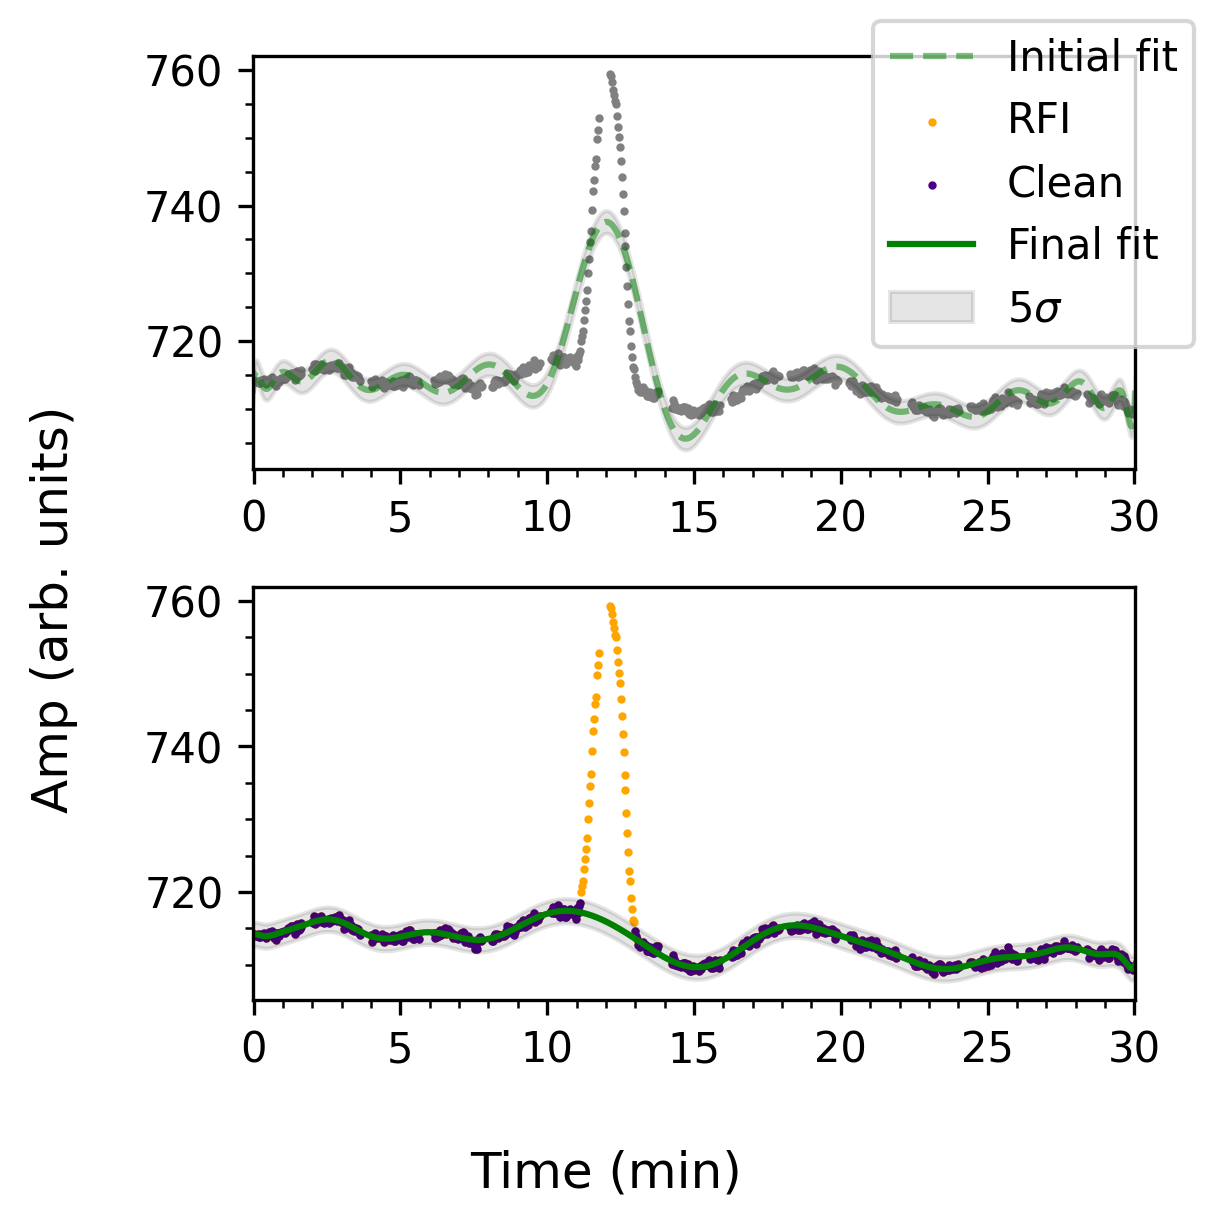

In [4]:
#Generate Legendre design matrix
x = np.linspace(-1, 1, smooth_time.shape[0])
design = legvander(x, 25)
print('Design matrix generated.')

#Initial fit
obs0 = ~np.isnan(padded_amp)
X = design[obs0]
c = la.solve(X.T @ X, X.T @ padded_amp[obs0])
mu0 = X @ c
res = (mu0 - padded_amp[obs0]) / (np.sqrt(4/np.pi-1)/np.sqrt(N_bl*N_freq) * mu0)
init_fit = design @ c


#Iteratively flagging outliers
flag_amp, flag_x = padded_amp.copy(), x.copy()
thresh = 5
while np.abs(res).max() >= thresh:
    obs = ~np.isnan(flag_amp)
    idx = np.where(obs)[0][np.argmax(np.abs(res))]
    flag_amp[idx] = np.nan
    obs = ~np.isnan(flag_amp)
    X = design[obs]
    c = la.solve(X.T @ X, X.T @ flag_amp[obs])
    mu = X @ c
    res = (mu - flag_amp[obs]) / (np.sqrt(4/np.pi-1)/np.sqrt(N_bl*N_freq) * mu)

#Final fit
obs = ~np.isnan(flag_amp)
X = design[obs]
c = la.solve(X.T @ X, X.T @ flag_amp[obs])
fit = design @ c
sigma = np.sqrt((fit**2)*(4/np.pi-1)/(N_bl*N_freq))
res = (flag_amp - fit)/sigma

## Plot
fig, ax = plt.subplots(figsize=(4,4), dpi=300, nrows=2)
ax[0].scatter((smooth_time-smooth_time.min()-dt)*60*24, padded_amp, s=1, color='grey')
ax[0].plot((smooth_time-smooth_time.min()-dt)*60*24, init_fit, alpha=0.5, label='Initial fit', color='g', linestyle='--')
ax[0].fill_between((smooth_time-smooth_time.min()-dt)*60*24, init_fit - thresh * sigma, 
                 init_fit + thresh * sigma, alpha=0.1, color='k')
ax[0].set_xlim((smooth_time-smooth_time.min()-dt).min()*60*24, (smooth_time-smooth_time.min()-dt).max()*60*24)
ax[0].minorticks_on()

ax[1].minorticks_on()
ax[1].scatter((smooth_time-smooth_time.min()-dt)*60*24, padded_amp, s=1, color='orange', label='RFI')
ax[1].scatter((smooth_time-smooth_time.min()-dt)*60*24, flag_amp, alpha=1, s=1, color='indigo', label='Clean')
ax[1].plot((smooth_time-smooth_time.min()-dt)*60*24, fit, alpha=1, color='g', label='Final fit')
ax[1].fill_between((smooth_time-smooth_time.min()-dt)*60*24, fit - thresh * sigma, 
                 fit + thresh * sigma, alpha=0.1, color='k', label=rf'${thresh}\sigma$')
ax[1].set_xlim((smooth_time-smooth_time.min()-dt).min()*60*24, (smooth_time-smooth_time.min()-dt).max()*60*24)
fig.supxlabel("Time (min)")
fig.supylabel("Amp (arb. units)")
fig.legend()
fig.tight_layout()
plt.show()

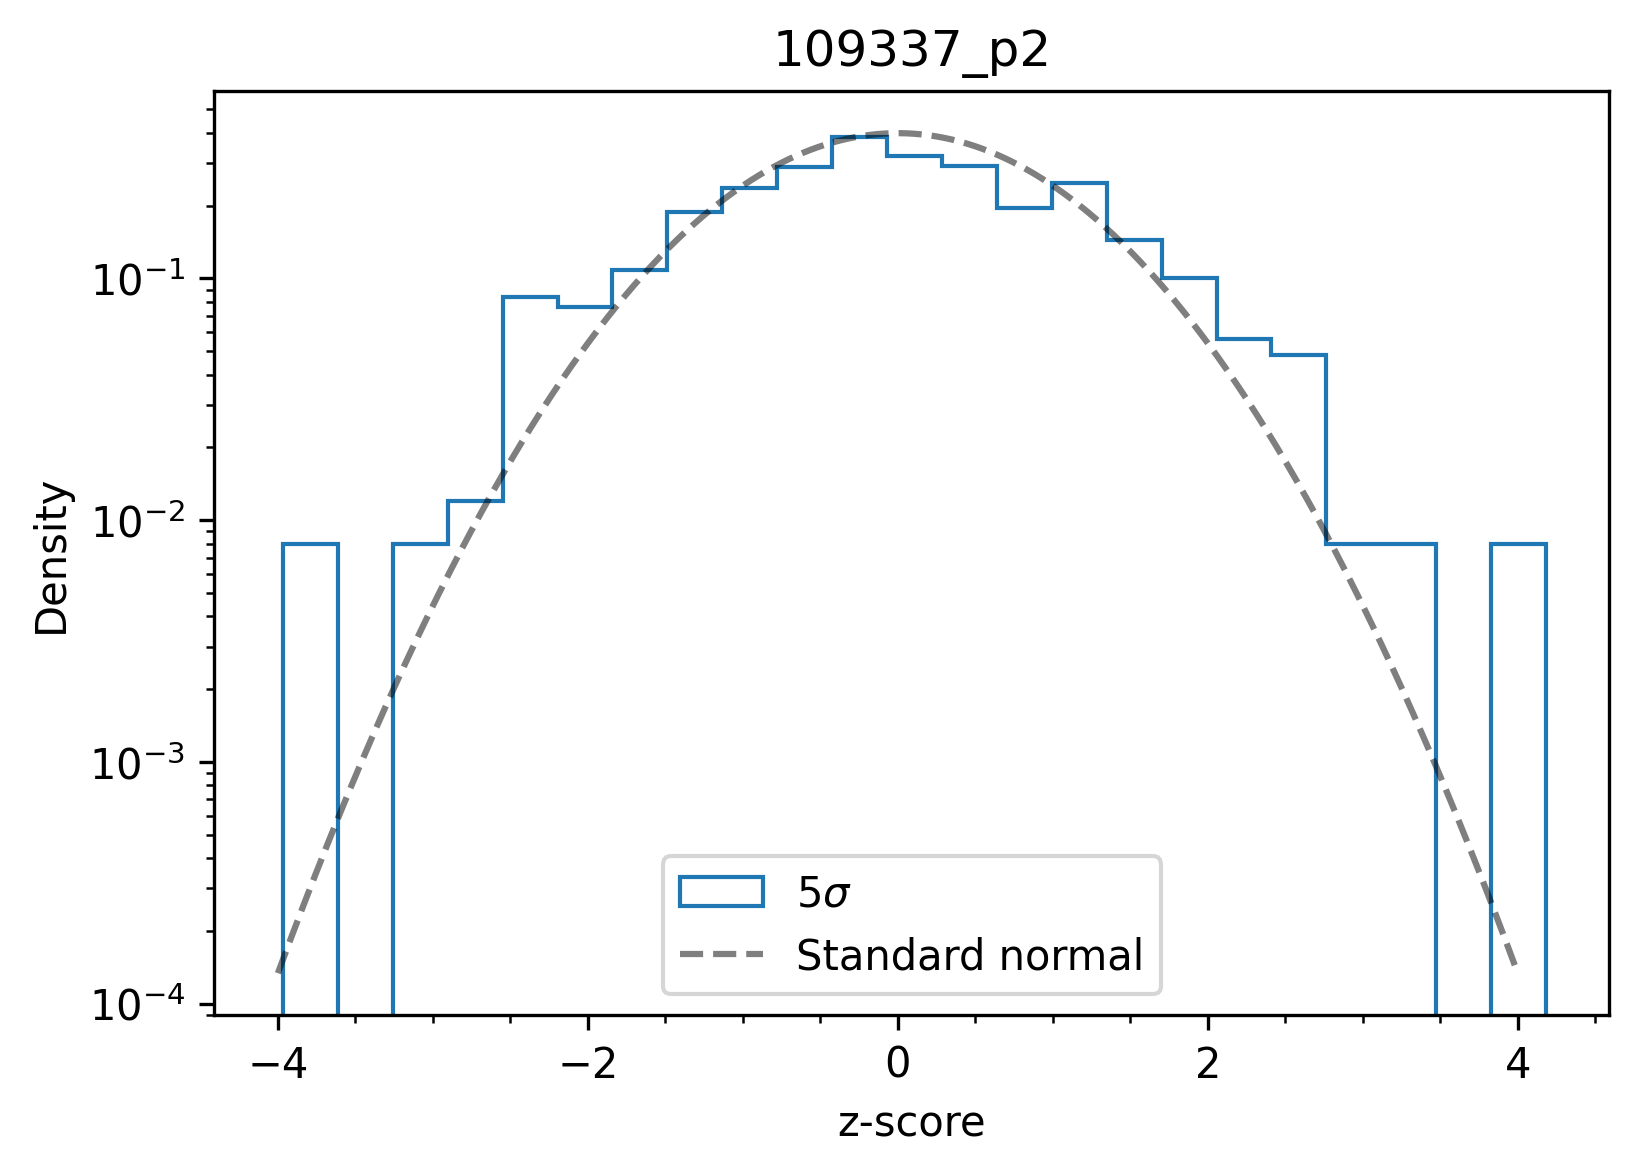

In [5]:
##Plotting z-score
z = np.linspace(-4, 4, 1000)
plt.figure(dpi=300, figsize=(6,4))
plt.title(f"{night}")
plt.hist(res, bins='auto', histtype='step', density='True', label=r'$5\sigma$')
plt.plot(z, np.exp(-z**2/2)/np.sqrt(2*np.pi), color='k', linestyle='--', label='Standard normal', alpha=0.5)
plt.yscale('log')
plt.legend()
plt.minorticks_on()
plt.xlabel('z-score')
plt.ylabel('Density')
plt.show()

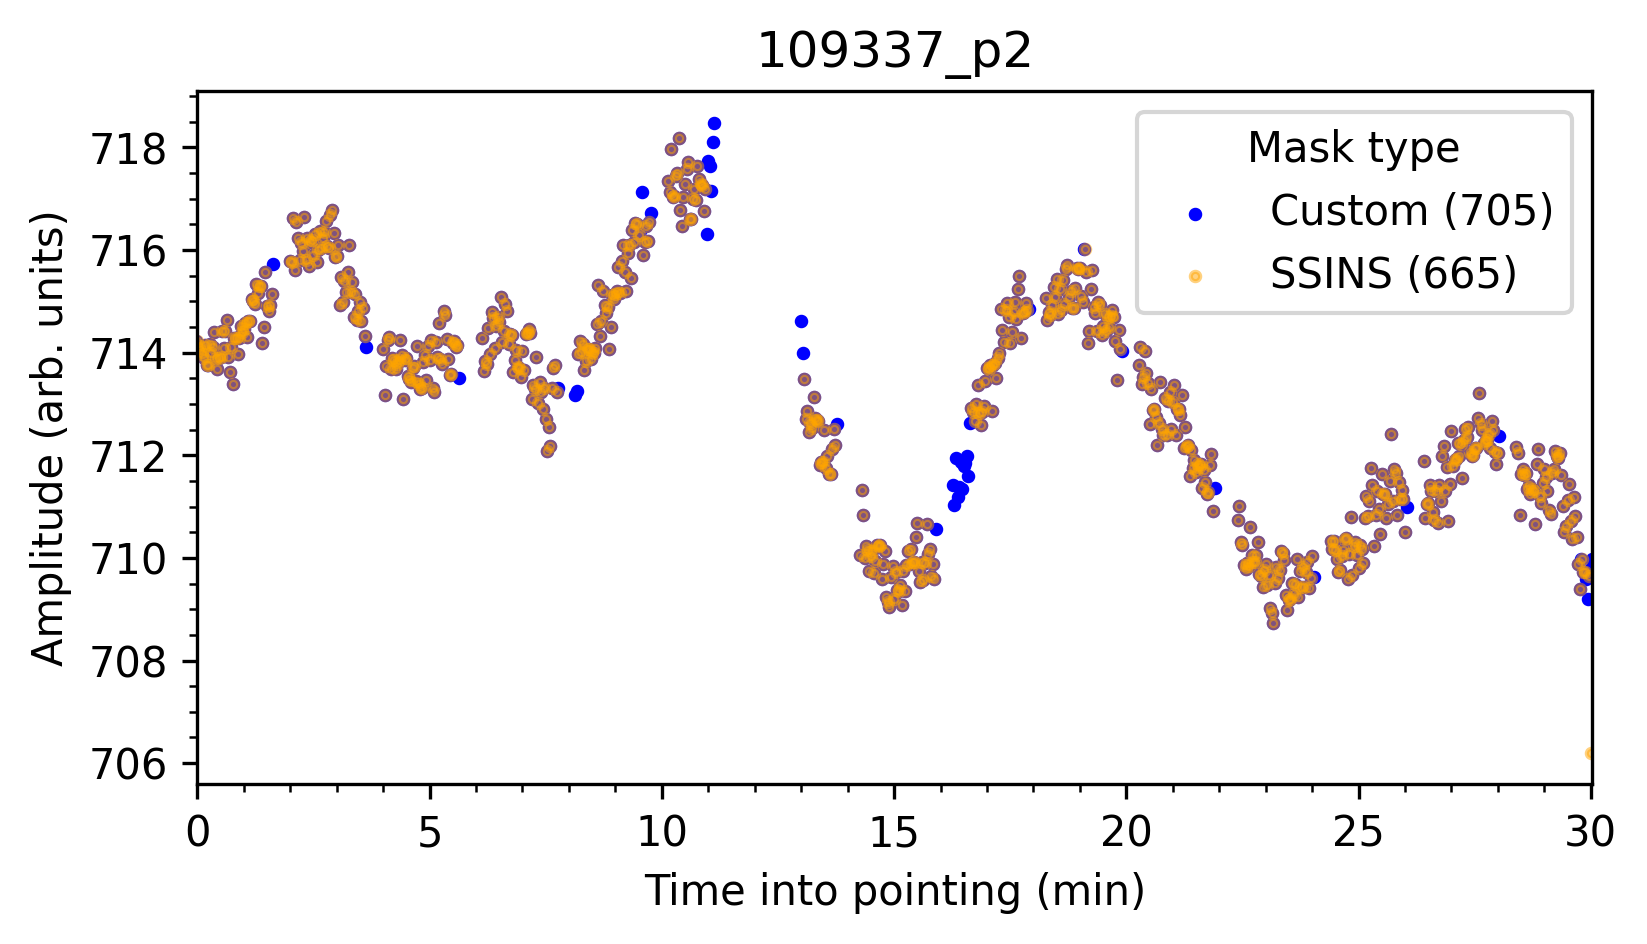

In [6]:
#Comparing custom flagger to SSINS flagger
plt.figure(figsize=(6,3), dpi=300)
plt.title(f"{night}")
plt.minorticks_on()
plt.xlim(0, (smooth_time-smooth_time.min()-dt)[obs].max()*60*24)
plt.scatter((smooth_time-smooth_time.min()-dt)[obs]*60*24, flag_amp[obs], s=5, label=f'Custom ({flag_amp[obs].shape[0]})', color='blue', alpha=1)
plt.scatter((masked_time-smooth_time.min())*60*24, masked_amp, s=5, label=f'SSINS ({masked_amp.shape[0]})', color='orange', alpha=0.5)
plt.legend(title='Mask type')
plt.xlabel('Time into pointing (min)')
plt.ylabel('Amplitude (arb. units)')
plt.show()

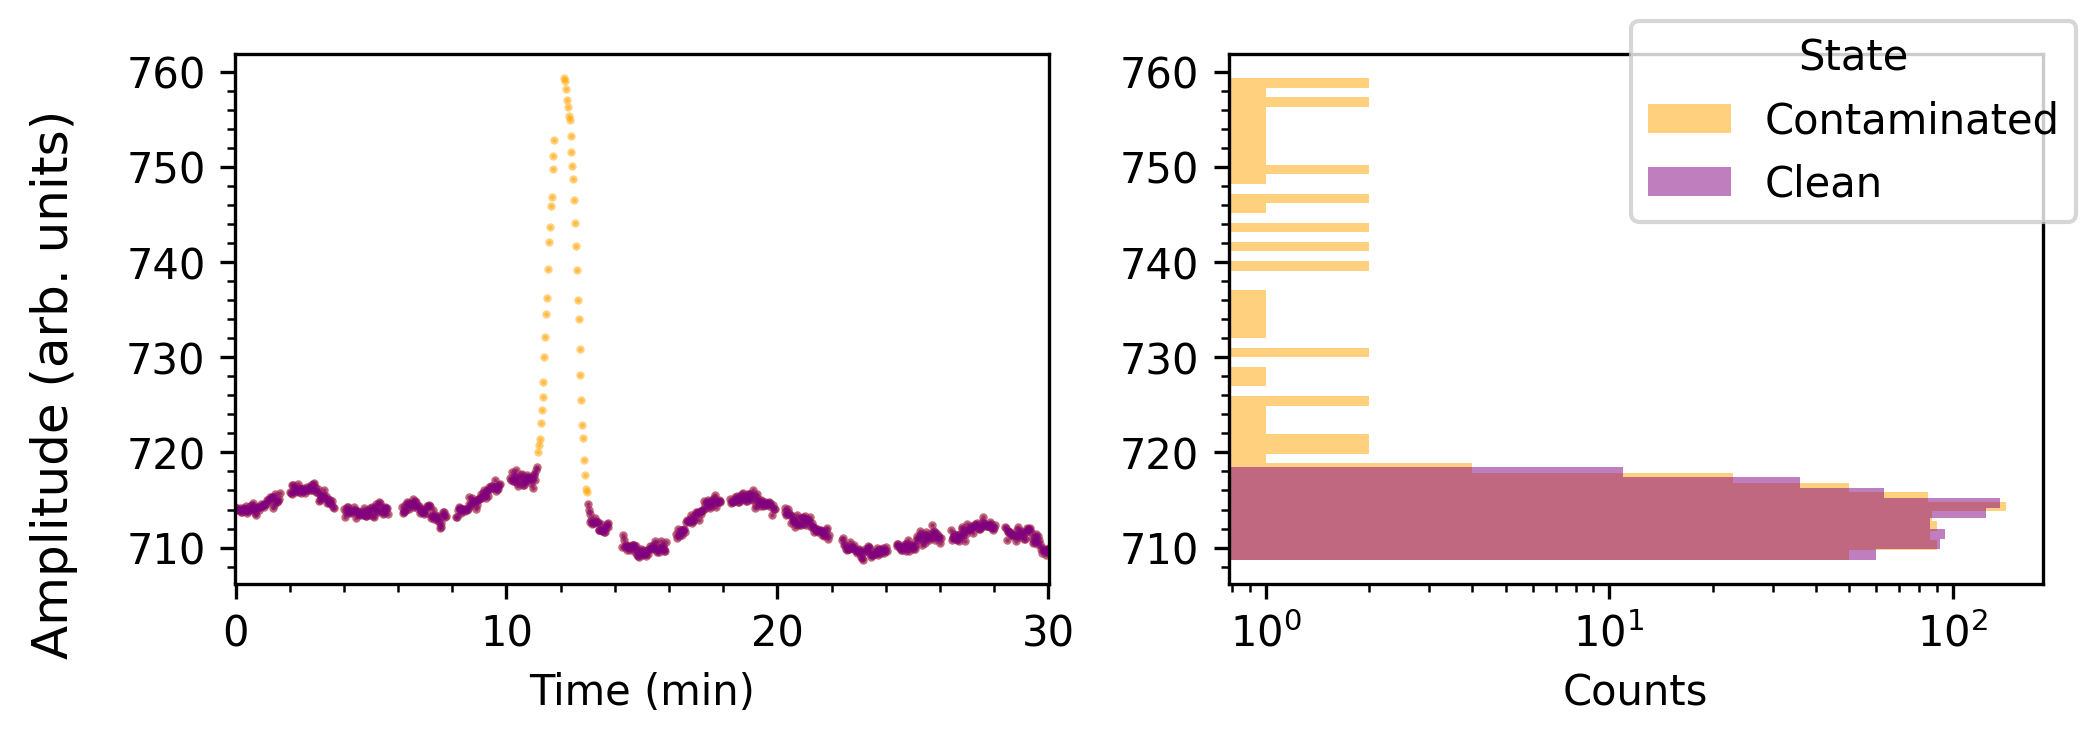

In [7]:
#Some more plotting code

fig, ax = plt.subplots(figsize=(7,2.5), dpi=300, ncols=2)
ax[0].scatter((smooth_time-smooth_time.min()-dt)*60*24, padded_amp, s=1, color='orange', alpha=0.5)
ax[0].scatter((smooth_time-smooth_time.min()-dt)*60*24, flag_amp, s=1, color='purple', alpha=0.5)
ax[0].set_xlim((smooth_time-smooth_time.min()-dt).min()*60*24, (smooth_time-smooth_time.min()-dt).max()*60*24)
ax[1].hist(amp, bins=int((amp.max()-amp.min())), alpha=0.5, label='Contaminated', color='orange', orientation='horizontal')
ax[1].hist(flag_amp, bins=int((flag_amp[~np.isnan(flag_amp)].max()-flag_amp[~np.isnan(flag_amp)].min())), alpha=0.5, label='Clean', color='purple', orientation='horizontal')
ax[1].set_xscale('log')
fig.supylabel("Amplitude (arb. units)")
ax[0].set_xlabel("Time (min)")
ax[1].set_xlabel("Counts")
ax[0].minorticks_on()
ax[1].minorticks_on()
fig.legend(title='State')
fig.tight_layout()